In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
# import cospar
import scanpy as sc

In [3]:
import os
# import cospar
import scanpy as sc
import pseudodynamics as pdp
import numpy as np
import pandas as pd

import palantir
from pseudodynamics import tl

import seaborn as sns
import matplotlib.pyplot as plt

/local/scratch/wz369/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/local/scratch/wz369/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Ann

In [4]:
os.chdir(pdp.main_dir)

In [5]:
import scvelo as scv

In [6]:
sc.set_figure_params(dpi=80, frameon=False)

In [7]:
pop_ad = sc.read_h5ad("data/klein/klein_addpop.h5ad")
pop_ad

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap', 'delta_DM', 'delta_PC', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [8]:
import palantir

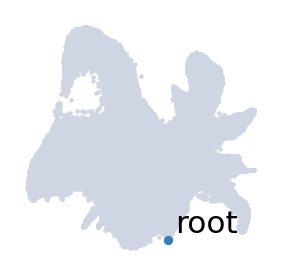

In [9]:
root_cb = '47528'
root_state = pd.Series(
    ['root'],
    index=[root_cb],
)
palantir.plot.highlight_cells_on_umap(pop_ad, root_state, figsize=(2,2));

In [ ]:
pr_res = palantir.core.run_palantir(
    pop_ad, root_cb,  num_waypoints=2500, 
    knn=50,
    # eigvec_key='DM_EigenVectors',
    use_early_cell_as_start= True
)

Sampling and flocking waypoints...


KeyboardInterrupt: 

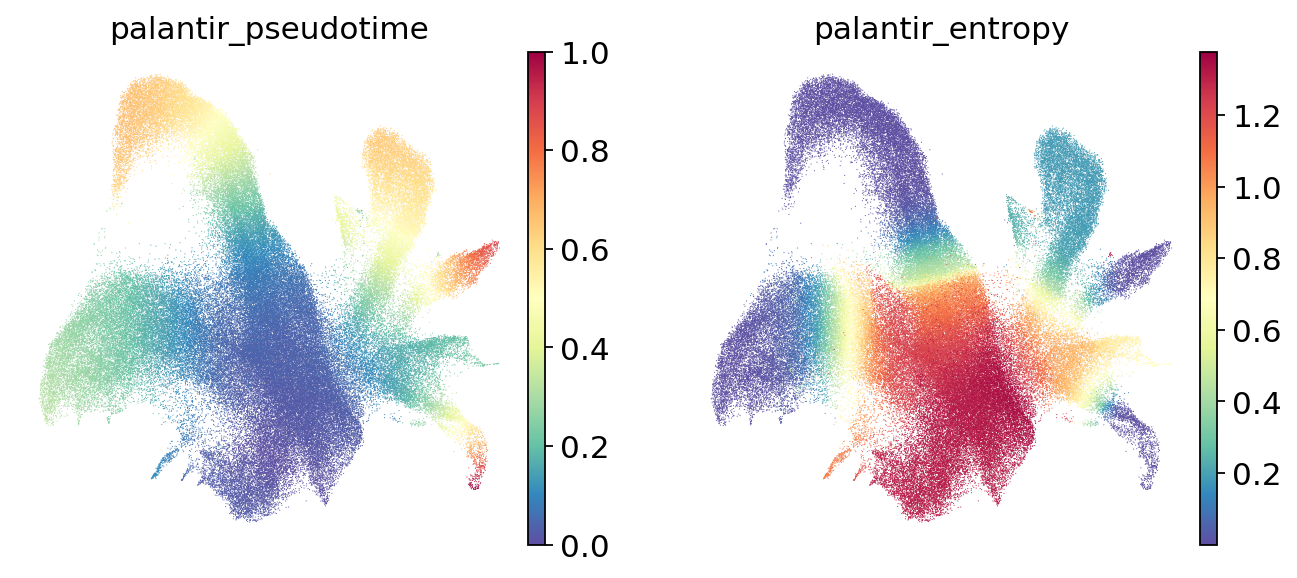

In [11]:
sc.pl.umap(pop_ad, color=['palantir_pseudotime','palantir_entropy'])

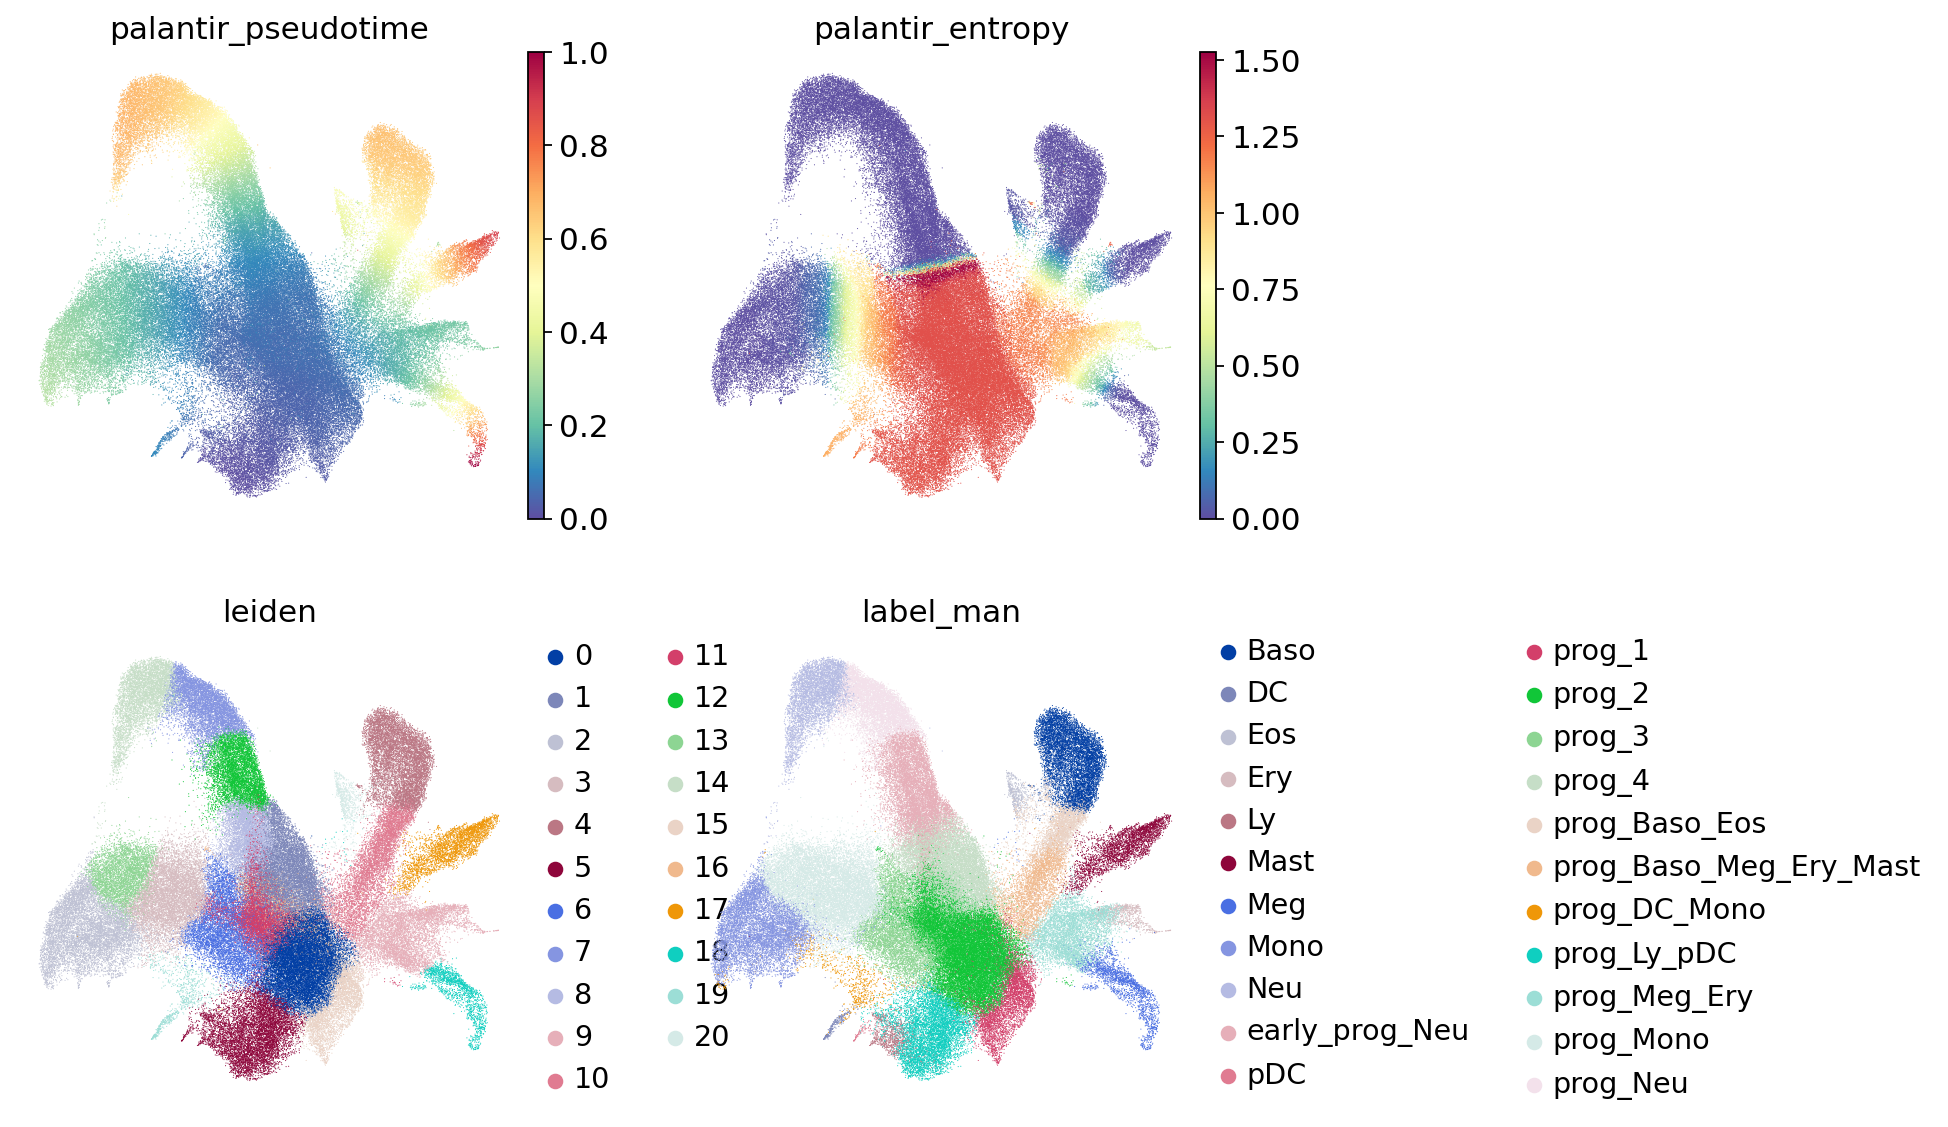

In [ ]:
sc.pl.umap(pop_ad, color=['palantir_pseudotime','palantir_entropy', 'leiden','label_man',], ncols=2)

In [11]:
def count_diverse_cell_indices(delta_neighbor):
    """
    Calculate the number of diverse cell indices across 10 sampling columns.
    
    Args:
        delta_neighbor: numpy array of shape (n_cell, 10) where each column contains cell indices
    
    Returns:
        Various diversity metrics
    """
    n_cells, n_samples = delta_neighbor.shape
    # assert n_samples == 10, "Expected 10 sampling columns"
    
    # Method 1: Count unique values per row (per cell)
    unique_per_row = []
    for i in range(n_cells):
        unique_count = len(np.unique(delta_neighbor[i, :]))
        unique_per_row.append(unique_count)
    
    unique_per_row = np.array(unique_per_row)
    
    # Method 2: Overall diversity - count total unique cell indices across entire matrix
    total_unique = len(np.unique(delta_neighbor))
    
    # Method 3: Average number of unique indices per cell
    avg_unique_per_cell = np.mean(unique_per_row)
    
    # Method 4: Distribution of unique counts
    unique_count_distribution = np.bincount(unique_per_row.astype(int), minlength=n_samples + 1)
    
    # Method 5: Diversity metrics per cell
    diversity_stats = {
        'unique_per_cell': unique_per_row,
        'total_unique_across_all': total_unique,
        'avg_unique_per_cell': avg_unique_per_cell,
        'min_unique_per_cell': np.min(unique_per_row),
        'max_unique_per_cell': np.max(unique_per_row),
        'diversity_distribution': unique_count_distribution
    }
    
    return diversity_stats


# visualize the delta DM

In [34]:
delta_X, neighbor_ls = tl.sample_deltax(pop_ad, 
                                        k = 150,
                                        xkey='DM_EigenVectors', 
                                        progressbar=True, 
                                        repeat=50)

100%|██████████| 126861/126861 [00:57<00:00, 2206.32it/s]


In [35]:
delta_DM = np.stack(delta_X)
print(delta_DM.shape)

delta_DM = np.transpose(delta_DM, (1,0,2))
print(delta_DM.shape)

pop_ad.obsm['delta_DM_Mar4'] = np.mean(delta_DM, axis=0)

(126861, 50, 10)
(50, 126861, 10)


(array([1.1810e+03, 2.0260e+04, 4.9003e+04, 2.9405e+04, 1.4009e+04,
        7.9750e+03, 3.8590e+03, 1.0170e+03, 1.3700e+02, 1.5000e+01]),
 array([ 1. ,  3.9,  6.8,  9.7, 12.6, 15.5, 18.4, 21.3, 24.2, 27.1, 30. ]),
 <BarContainer object of 10 artists>)

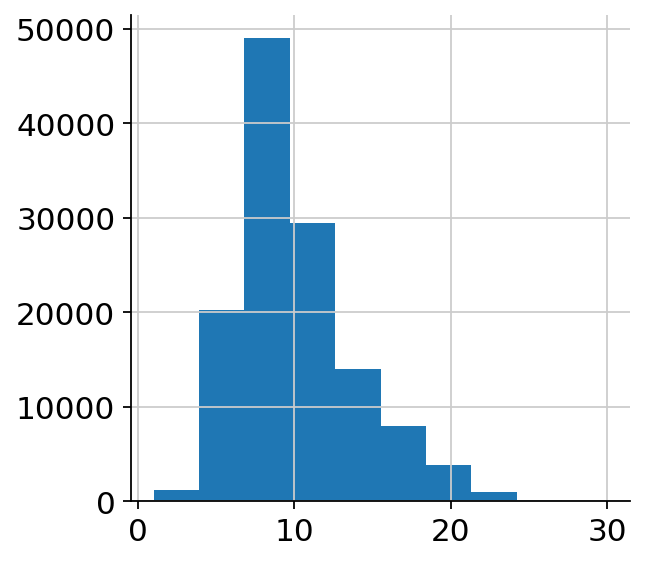

In [28]:
delta_neighbor = np.stack(neighbor_ls)
diversity_metrics = count_diverse_cell_indices(delta_neighbor)
plt.hist(diversity_metrics['unique_per_cell'], bins=10)

In [36]:
DM_ad = pdp.tl.make_coord_adata(pop_ad, "DM_EigenVectors",n_dimension=10)
sc.pp.neighbors(DM_ad, n_neighbors=150)

computing velocity graph (using 1/128 cores)


  0%|          | 0/126861 [00:00<?, ?cells/s]

    finished (0:02:19) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:27) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


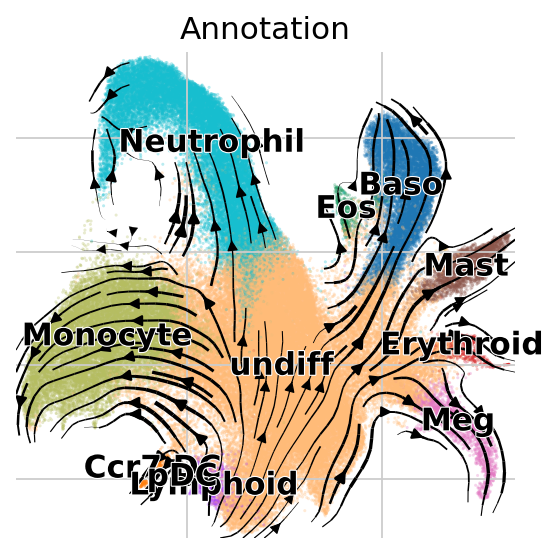

In [37]:
DM_ad.layers['velocity'] = pop_ad.obsm['delta_DM_Mar4']
scv.tl.velocity_graph(DM_ad, xkey='cellstate', vkey='velocity', n_jobs=None)
scv.pl.velocity_embedding_stream(DM_ad, 
                                 basis='X_umap', color='Annotation',
                                 density= 1.5, smooth=None
                                 )

Old

In [ ]:
DM_ad.layers['velocity'] = DM_ad.obsm['delta_DM']
scv.tl.velocity_graph(DM_ad, xkey='cellstate', vkey='velocity', n_jobs=None)
scv.pl.velocity_embedding_stream(DM_ad, 
                                 basis='X_umap', color='Annotation',
                                 density= 1.5, smooth=None
                                 )

computing velocity graph (using 1/128 cores)


  0%|          | 0/126861 [00:00<?, ?cells/s]

    finished (0:00:33) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Visualize delta pc

In [18]:
PC_ad = pdp.tl.make_coord_adata(pop_ad, "X_pca",n_dimension=50)
PC_ad.layers['velocity'] = PC_ad.obsm['delta_PC']
PC_ad

AnnData object with n_obs × n_vars = 126861 × 50
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap', 'delta_DM', 'delta_PC', 'palantir_fate_probabilities', 'delta_DM_Mar4'
    layers: 'cellstate', 'velocity'
    obsp: 'connectivities', 'distances'

In [19]:
sc.pp.neighbors(PC_ad, n_neighbors=15)
scv.tl.velocity_graph(PC_ad, xkey='cellstate', vkey='velocity', n_jobs=10)

computing velocity graph (using 10/128 cores)


  0%|          | 0/126861 [00:00<?, ?cells/s]

    finished (0:00:28) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:20) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


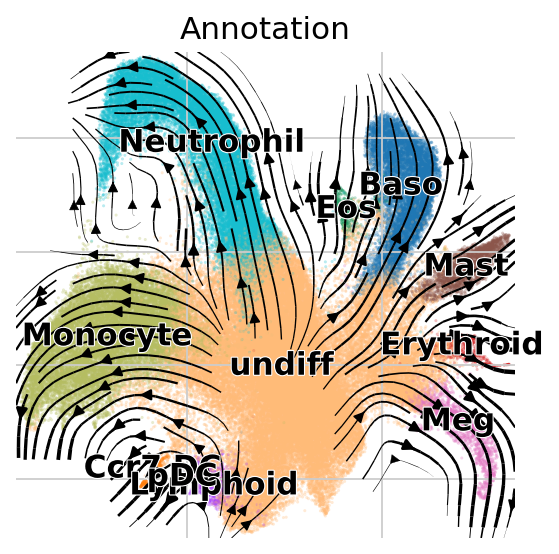

In [20]:
scv.pl.velocity_embedding_stream(PC_ad, 
                                 basis='X_umap', color='Annotation',
                                 density= 1.5, smooth=1
                                 )

In [21]:
delta_Xpca, neighbor_ls = tl.sample_deltax(pop_ad, 
                                        k = 50,
                                        xkey='X_pca', 
                                        progressbar=True, 
                                        repeat=50)

100%|██████████| 126861/126861 [00:56<00:00, 2235.71it/s]


In [22]:
delta_PC = np.stack(delta_Xpca)
print(delta_PC.shape)

delta_PC = np.transpose(delta_PC, (1,0,2))
print(delta_PC.shape)

pop_ad.obsm['delta_PC_Mar4'] = np.mean(delta_PC, axis=0)

(126861, 50, 50)
(50, 126861, 50)


(array([1.4570e+03, 2.0305e+04, 4.8232e+04, 2.9630e+04, 1.4239e+04,
        8.0350e+03, 3.7780e+03, 1.0430e+03, 1.2500e+02, 1.7000e+01]),
 array([ 1.,  4.,  7., 10., 13., 16., 19., 22., 25., 28., 31.]),
 <BarContainer object of 10 artists>)

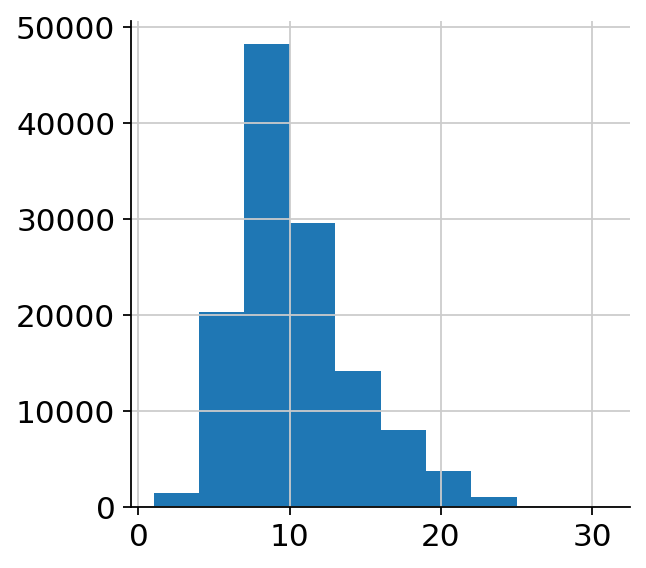

In [23]:
delta_neighbor = np.stack(neighbor_ls)
diversity_metrics = count_diverse_cell_indices(delta_neighbor)
plt.hist(diversity_metrics['unique_per_cell'], bins=10)

In [29]:
PC_ad = pdp.tl.make_coord_adata(pop_ad, "X_pca",n_dimension=50)
sc.pp.neighbors(PC_ad, n_neighbors=15)
PC_ad

AnnData object with n_obs × n_vars = 126861 × 50
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap', 'delta_DM', 'delta_PC', 'palantir_fate_probabilities', 'delta_DM_Mar4', 'delta_PC_Mar4'
    layers: 'cellstate'
    obsp: 'connectivities', 'distances'

In [32]:
PC_ad.layers['velocity'] = pop_ad.obsm['delta_PC_Mar4']
scv.tl.velocity_graph(PC_ad, xkey='cellstate', vkey='velocity', n_jobs=None)

computing velocity graph (using 1/128 cores)


  0%|          | 0/126861 [00:00<?, ?cells/s]

    finished (0:00:44) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:21) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


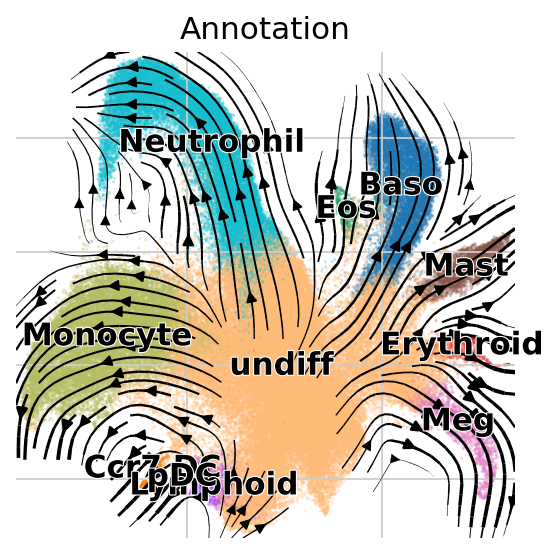

In [33]:
scv.pl.velocity_embedding_stream(PC_ad, 
                                 basis='X_umap', color='Annotation',
                                 density= 1.5, smooth=1
                                 )